# Lifetime


In [20]:
import numpy as np
import xarray as xr 
import matplotlib.pyplot as plt
import scipy.signal as signal

import cartopy
import cartopy.crs as ccrs
import cartopy.feature       as cfeature
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

import netCDF4 as nc
import os
import matplotlib.dates as mdates

In [8]:
# Parameters
url_drifters = "drifter_carthe006-ime_carthe001/L0/2023/dep0002_drifter-carthe006_ime-carthe001_L0_2023-04-26.nc?"

drifter_type = 'C' # C: CARTHE ; H: Hereon ; S: SVP-B 
diff_time_thres = 3600 # [s] 1h # Will be different for SVP, higher as time res. is 1hr

temp_res = 600. # Specifying seconds 
# Step depending on drifter (CARTHE and HEREON 600s (10 mins (we choose the highest time resolution)) 
# and SVP-B (1h))

# n_window = 12 # we leave like this for now

# Leg 1:

In [9]:
url_drifters = []

#"drifter_carthe006-ime_carthe001/L0/2023/dep0002_drifter-carthe006_ime-carthe001_L0_2023-04-26.nc?"


In [10]:
mm = '4'.zfill(2)

#8: 27/04
drifter_num = '8'.zfill(3)
# for some reason to id numbers..
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '27'.zfill(2)
url_01 = "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L0/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L0_2023-" + mm + "-" + dd + ".nc?"
url_drifters.append(url_01)
print(url_01)

#07: 27/04
drifter_num = '7'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '27'.zfill(2)
url_01 = "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L0/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L0_2023-" + mm + "-" + dd + ".nc?"
url_drifters.append(url_01)
print(url_01)

#06: 27/04
drifter_num = '6'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '27'.zfill(2)
url_01 = "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L0/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L0_2023-" + mm + "-" + dd + ".nc?"
url_drifters.append(url_01)
print(url_01)
      
#05: 27/04
drifter_num = '5'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '27'.zfill(2)
url_01 = "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L0/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L0_2023-" + mm + "-" + dd + ".nc?"
url_drifters.append(url_01)
print(url_01)

#04: 27/04
drifter_num = '4'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '27'.zfill(2)
url_01 = "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L0/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L0_2023-" + mm + "-" + dd + ".nc?"
url_drifters.append(url_01)
print(url_01)

#03: 26/04
drifter_num = '3'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '26'.zfill(2)
url_01 = "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L0/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L0_2023-" + mm + "-" + dd + ".nc?" 
url_drifters.append(url_01)
print(url_01)

#02: 26/04
drifter_num = '2'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '26'.zfill(2)
url_01 = "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L0/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L0_2023-" + mm + "-" + dd + ".nc?" 
url_drifters.append(url_01)
print(url_01)

#01: 26/04
drifter_num = '1'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '26'.zfill(2)
# attention! prev trial done, so here dep0001_ is dep0002_
url_01 = "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L0/2023/dep0002_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L0_2023-" + mm + "-" + dd + ".nc?" 
url_drifters.append(url_01)
print(url_01)

#09: 24/04
drifter_num = '9'.zfill(3)
drifter_num2 = str(int(drifter_num) + 5).zfill(3)
dd = '28'.zfill(2)
# url_01 = "drifter_carthe" + drifter_num2 + "-ime_carthe" + drifter_num + "/L0/2023/dep0001_drifter-carthe" + drifter_num2 + "_ime-carthe" + drifter_num + "_L0_2023-" + mm + "-" + dd + ".nc?" 
url_02 = 'drifter_carthe014-ime_carthe009/L0/2023/dep0001_drifter-carthe014_ime-carthe009_L0_2023-04-28.nc?'
url_drifters.append(url_02)
print(url_02)

# 10: 
url_01 = "drifter_carthe015-ime_carthe010/L1/2023/dep0001_drifter-carthe015_ime-carthe010_L1_2023-04-28.nc?" 
url_drifters.append(url_01)
print(url_01)

drifter_carthe013-ime_carthe008/L0/2023/dep0001_drifter-carthe013_ime-carthe008_L0_2023-04-27.nc?
drifter_carthe012-ime_carthe007/L0/2023/dep0001_drifter-carthe012_ime-carthe007_L0_2023-04-27.nc?
drifter_carthe011-ime_carthe006/L0/2023/dep0001_drifter-carthe011_ime-carthe006_L0_2023-04-27.nc?
drifter_carthe010-ime_carthe005/L0/2023/dep0001_drifter-carthe010_ime-carthe005_L0_2023-04-27.nc?
drifter_carthe009-ime_carthe004/L0/2023/dep0001_drifter-carthe009_ime-carthe004_L0_2023-04-27.nc?
drifter_carthe008-ime_carthe003/L0/2023/dep0001_drifter-carthe008_ime-carthe003_L0_2023-04-26.nc?
drifter_carthe007-ime_carthe002/L0/2023/dep0001_drifter-carthe007_ime-carthe002_L0_2023-04-26.nc?
drifter_carthe006-ime_carthe001/L0/2023/dep0002_drifter-carthe006_ime-carthe001_L0_2023-04-26.nc?
drifter_carthe014-ime_carthe009/L0/2023/dep0001_drifter-carthe014_ime-carthe009_L0_2023-04-28.nc?
drifter_carthe015-ime_carthe010/L1/2023/dep0001_drifter-carthe015_ime-carthe010_L1_2023-04-28.nc?


In [11]:
url_drifters

['drifter_carthe013-ime_carthe008/L0/2023/dep0001_drifter-carthe013_ime-carthe008_L0_2023-04-27.nc?',
 'drifter_carthe012-ime_carthe007/L0/2023/dep0001_drifter-carthe012_ime-carthe007_L0_2023-04-27.nc?',
 'drifter_carthe011-ime_carthe006/L0/2023/dep0001_drifter-carthe011_ime-carthe006_L0_2023-04-27.nc?',
 'drifter_carthe010-ime_carthe005/L0/2023/dep0001_drifter-carthe010_ime-carthe005_L0_2023-04-27.nc?',
 'drifter_carthe009-ime_carthe004/L0/2023/dep0001_drifter-carthe009_ime-carthe004_L0_2023-04-27.nc?',
 'drifter_carthe008-ime_carthe003/L0/2023/dep0001_drifter-carthe008_ime-carthe003_L0_2023-04-26.nc?',
 'drifter_carthe007-ime_carthe002/L0/2023/dep0001_drifter-carthe007_ime-carthe002_L0_2023-04-26.nc?',
 'drifter_carthe006-ime_carthe001/L0/2023/dep0002_drifter-carthe006_ime-carthe001_L0_2023-04-26.nc?',
 'drifter_carthe014-ime_carthe009/L0/2023/dep0001_drifter-carthe014_ime-carthe009_L0_2023-04-28.nc?',
 'drifter_carthe015-ime_carthe010/L1/2023/dep0001_drifter-carthe015_ime-carthe010_

In [60]:
rootdir = '/Users/Gomez023/Postdoc/data/'
savedir = rootdir + 'FaST-SWOT/drifters/'

In [61]:
savedir

'/Users/Gomez023/Postdoc/data/FaST-SWOT/drifters/'

In [64]:
!ls /Users/Gomez023/Postdoc/data/FaST-SWOT/drifters/CARTHE/L0_SOCIB/

CARTHE_4694040.nc CARTHE_4694193.nc CARTHE_4694206.nc CARTHE_4694473.nc
CARTHE_4694103.nc CARTHE_4694198.nc CARTHE_4694223.nc CARTHE_4694474.nc
CARTHE_4694122.nc CARTHE_4694199.nc CARTHE_4694458.nc CARTHE_4694475.nc
CARTHE_4694188.nc CARTHE_4694201.nc CARTHE_4694461.nc CARTHE_4694476.nc
CARTHE_4694189.nc CARTHE_4694203.nc CARTHE_4694462.nc CARTHE_4695850.nc


In [65]:
carthe_L0 = '/Users/Gomez023/Postdoc/data/FaST-SWOT/drifters/CARTHE/L0_SOCIB/'

In [66]:
from glob import glob
myfiles_C_L0 = sorted(glob(carthe_L0 + '**.nc')) #[1-3]


In [17]:
def reading_SOCIB_LO(url_drifter_n, drifter_type):
    # Main root
    url_root = "http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/"

    # parameters of the thredd file

    if drifter_type == 'C':
        url_vars = "trajectory,time[0:1:-1],DEPTH,LAT[0:1:-1],LON[0:1:-1],BAT_STATUS[0:1:-1]"
        temp_res = 600. # Specifying seconds 
        # Step depending on drifter (CARTHE and HEREON 600s (10 mins (we choose the highest time resolution)) 
    elif drifter_type == 'H':
        url_vars = "trajectory,time[0:1:-1],LAT[0:1:-1],LON[0:1:-1],DEPTH,PLAT_SPEED_GR[0:1:-1],PLAT_COURSE[0:1:-1],BAT_STATUS[0:1:-1]"
        temp_res = 600. # Specifying seconds 
        # Step depending on drifter (CARTHE and HEREON 600s (10 mins (we choose the highest time resolution)) 
    elif drifter_type == 'S':
        url_vars = "trajectory,time[0:1:-1],DEPTH,WTEM[0:1:-1],VOLT[0:1:-1],LAT[0:1:-1],DROGUE[0:1:-1],LON[0:1:-1],APRE[0:1:-1]"
        temp_res = 3600. # Specifying seconds 
    else:
        print('SVP missing temp , press , BAT_status different')
        fsdfs

    # Load file

    url = url_root + url_drifter_n + url_vars
    
    print(url)

    dsn = xr.open_dataset(url)
    return dsn

In [18]:
ds = reading_SOCIB_LO(url_drifters[0], 'C')

http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe013-ime_carthe008/L0/2023/dep0001_drifter-carthe013_ime-carthe008_L0_2023-04-27.nc?trajectory,time[0:1:-1],DEPTH,LAT[0:1:-1],LON[0:1:-1],BAT_STATUS[0:1:-1]


In [19]:
ds.time

<xarray.DataArray 'time' (time: 4897)>
array(['2023-04-27T23:40:56.000000000', '2023-04-27T23:44:16.000000000',
       '2023-04-27T23:54:18.000000000', ..., '2023-06-01T01:53:59.000000000',
       '2023-06-01T02:04:04.000000000', '2023-06-01T02:14:04.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2023-04-27T23:40:56 ... 2023-06-01T02:14:04
    DEPTH    float64 ...
    LAT      (time) float64 ...
    LON      (time) float64 ...
Attributes:
    standard_name:  time
    axis:           T

In [45]:
# Function to read NetCDF files and extract start and end dates for each trajectory
def get_trajectory_dates(netcdf_files, drifter_type):
    trajectory_dates = []
    for file in netcdf_files:
        ds = reading_SOCIB_LO(file, drifter_type)
        times = ds['time'].values
        start_date = np.min(times)
        end_date = np.max(times)
        trajectory_dates.append((start_date, end_date))
        ds.close()
    return trajectory_dates

In [59]:
# Compute the start and end dates
trajectory_dates = get_trajectory_dates(url_drifters, "C")

http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe013-ime_carthe008/L0/2023/dep0001_drifter-carthe013_ime-carthe008_L0_2023-04-27.nc?trajectory,time[0:1:-1],DEPTH,LAT[0:1:-1],LON[0:1:-1],BAT_STATUS[0:1:-1]
http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe012-ime_carthe007/L0/2023/dep0001_drifter-carthe012_ime-carthe007_L0_2023-04-27.nc?trajectory,time[0:1:-1],DEPTH,LAT[0:1:-1],LON[0:1:-1],BAT_STATUS[0:1:-1]
http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe011-ime_carthe006/L0/2023/dep0001_drifter-carthe011_ime-carthe006_L0_2023-04-27.nc?trajectory,time[0:1:-1],DEPTH,LAT[0:1:-1],LON[0:1:-1],BAT_STATUS[0:1:-1]
http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe010-ime_carthe005/L0/2023/dep0001_drifter-carthe010_ime-carthe005_L0_2023-04-27.nc?trajectory,time[0:1:-1],DEPTH,LAT[0:1:-1],LON[0:1:-1],BAT_STATUS[0:1:-1]


syntax error, unexpected WORD_WORD, expecting SCAN_ATTR or SCAN_DATASET or SCAN_ERROR
context: <html^><head><script async src="https://www.googletagmanager.com/gtag/js?id=G-2DVXD3M3LB"></script><script>window.dataLayer = window.dataLayer || [];function gtag(){dataLayer.push(arguments);}gtag("js", new Date());gtag("config", "G-2DVXD3M3LB");</script><title>503 Service Temporarily Unavailable</title></head><body bgcolor="white"><center><h1>503 Service Temporarily Unavailable</h1></center><hr><center>nginx/1.10.3 (Ubuntu)</center></body></html>


http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe009-ime_carthe004/L0/2023/dep0001_drifter-carthe009_ime-carthe004_L0_2023-04-27.nc?trajectory,time[0:1:-1],DEPTH,LAT[0:1:-1],LON[0:1:-1],BAT_STATUS[0:1:-1]


syntax error, unexpected WORD_WORD, expecting SCAN_ATTR or SCAN_DATASET or SCAN_ERROR
context: <html^><head><script async src="https://www.googletagmanager.com/gtag/js?id=G-2DVXD3M3LB"></script><script>window.dataLayer = window.dataLayer || [];function gtag(){dataLayer.push(arguments);}gtag("js", new Date());gtag("config", "G-2DVXD3M3LB");</script><title>503 Service Temporarily Unavailable</title></head><body bgcolor="white"><center><h1>503 Service Temporarily Unavailable</h1></center><hr><center>nginx/1.10.3 (Ubuntu)</center></body></html>


http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe008-ime_carthe003/L0/2023/dep0001_drifter-carthe008_ime-carthe003_L0_2023-04-26.nc?trajectory,time[0:1:-1],DEPTH,LAT[0:1:-1],LON[0:1:-1],BAT_STATUS[0:1:-1]


syntax error, unexpected WORD_WORD, expecting SCAN_ATTR or SCAN_DATASET or SCAN_ERROR
context: <html^><head><script async src="https://www.googletagmanager.com/gtag/js?id=G-2DVXD3M3LB"></script><script>window.dataLayer = window.dataLayer || [];function gtag(){dataLayer.push(arguments);}gtag("js", new Date());gtag("config", "G-2DVXD3M3LB");</script><title>503 Service Temporarily Unavailable</title></head><body bgcolor="white"><center><h1>503 Service Temporarily Unavailable</h1></center><hr><center>nginx/1.10.3 (Ubuntu)</center></body></html>


OSError: [Errno -70] NetCDF: DAP server error: b'http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe008-ime_carthe003/L0/2023/dep0001_drifter-carthe008_ime-carthe003_L0_2023-04-26.nc?trajectory,time[0:1:-1],DEPTH,LAT[0:1:-1],LON[0:1:-1],BAT_STATUS[0:1:-1]'

In [49]:
trajectory_dates

[(numpy.datetime64('2023-04-26T18:08:15.000000000'),
  numpy.datetime64('2023-06-04T17:14:11.000000000')),
 (numpy.datetime64('2023-04-26T14:06:05.000000000'),
  numpy.datetime64('2023-05-19T00:30:06.000000000')),
 (numpy.datetime64('2023-04-26T10:16:51.000000000'),
  numpy.datetime64('2023-05-28T19:14:18.000000000')),
 (numpy.datetime64('2023-04-28T00:47:10.000000000'),
  numpy.datetime64('2023-07-13T10:57:42.000000000')),
 (numpy.datetime64('2023-04-28T01:16:54.000000000'),
  numpy.datetime64('2023-09-14T10:22:46.000000000'))]

In [50]:
# Extract filenames without extensions to use as trajectory names
trajectory_names = [os.path.splitext(os.path.basename(file))[0].split('_')[2] for file in url_drifters]
trajectory_names


['ime-carthe008',
 'ime-carthe007',
 'ime-carthe006',
 'ime-carthe005',
 'ime-carthe004',
 'ime-carthe003',
 'ime-carthe002',
 'ime-carthe001',
 'ime-carthe009',
 'ime-carthe010']

In [51]:
url_drifters

['drifter_carthe013-ime_carthe008/L0/2023/dep0001_drifter-carthe013_ime-carthe008_L0_2023-04-27.nc?',
 'drifter_carthe012-ime_carthe007/L0/2023/dep0001_drifter-carthe012_ime-carthe007_L0_2023-04-27.nc?',
 'drifter_carthe011-ime_carthe006/L0/2023/dep0001_drifter-carthe011_ime-carthe006_L0_2023-04-27.nc?',
 'drifter_carthe010-ime_carthe005/L0/2023/dep0001_drifter-carthe010_ime-carthe005_L0_2023-04-27.nc?',
 'drifter_carthe009-ime_carthe004/L0/2023/dep0001_drifter-carthe009_ime-carthe004_L0_2023-04-27.nc?',
 'drifter_carthe008-ime_carthe003/L0/2023/dep0001_drifter-carthe008_ime-carthe003_L0_2023-04-26.nc?',
 'drifter_carthe007-ime_carthe002/L0/2023/dep0001_drifter-carthe007_ime-carthe002_L0_2023-04-26.nc?',
 'drifter_carthe006-ime_carthe001/L0/2023/dep0002_drifter-carthe006_ime-carthe001_L0_2023-04-26.nc?',
 'drifter_carthe014-ime_carthe009/L0/2023/dep0001_drifter-carthe014_ime-carthe009_L0_2023-04-28.nc?',
 'drifter_carthe015-ime_carthe010/L1/2023/dep0001_drifter-carthe015_ime-carthe010_

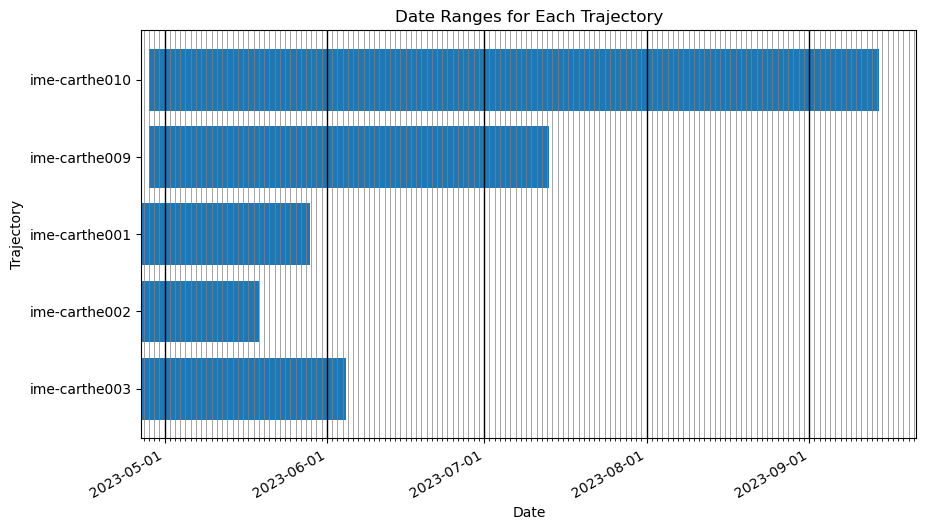

In [58]:
# Create the plot with bars showing the date ranges
plt.figure(figsize=(10, 6))

# Plot each trajectory as a horizontal bar
for ii, (start_date, end_date) in enumerate(trajectory_dates):
    plt.barh(trajectory_names[5::][ii], end_date - start_date, color='C0', left=start_date, align='center')

# Format the x-axis to show dates properly
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_minor_locator(mdates.DayLocator())

# plt.grid()
# Display grid lines for better visualization
ax.grid(True, which='major', axis='x', color='black', linestyle='-', linewidth=1)
ax.grid(True, which='minor', axis='x', color='grey', linestyle='-', linewidth=0.5)

plt.xlabel('Date')
plt.ylabel('Trajectory')
plt.title('Date Ranges for Each Trajectory')
plt.gcf().autofmt_xdate()  # Rotate date labels for better readability
plt.show()